In [3]:
!pip install transformers torch -q

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
#Configuration
import pandas as pd
import numpy as np
import os
import re
import unicodedata
import matplotlib.pyplot as plt

# Seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
BASE_PATH = "/content/drive/MyDrive/Newslens.lk"
RESULTS_DIR = f"{BASE_PATH}/aggregation_pipeline/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results dir: {RESULTS_DIR}")



Results dir: /content/drive/MyDrive/Newslens.lk/aggregation_pipeline/results


In [6]:
import pandas as pd
import numpy as np

df_a = pd.read_csv(f'{BASE_PATH}/ashini.csv')
df_d = pd.read_csv(f'{BASE_PATH}/dinithi.csv')
df_p = pd.read_csv(f'{BASE_PATH}/praveen.csv')

In [7]:
# concatenate dataframes and drop duplicate articles (by article_id)
df = pd.concat([df_a, df_d, df_p], ignore_index=True, sort=False)
df = df.drop_duplicates(subset='article_id', keep='first').reset_index(drop=True)
df.drop(columns=["bias_label"], inplace=True)

# quick check
print("df shape:", df.shape)
df.head()
df.info()

df shape: (2000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    2000 non-null   object
 1   publisher     2000 non-null   object
 2   url           2000 non-null   object
 3   published_at  2000 non-null   object
 4   title         2000 non-null   object
 5   body_text     2000 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB


In [8]:
# drop rows with any null values
df.dropna(inplace=True)
print("df shape after dropna:", df.shape)
df.info()


df shape after dropna: (2000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    2000 non-null   object
 1   publisher     2000 non-null   object
 2   url           2000 non-null   object
 3   published_at  2000 non-null   object
 4   title         2000 non-null   object
 5   body_text     2000 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB


In [9]:
#Unicode normalization (NFC - canonical decomposition + composition)
import unicodedata

# Unicode normalization (NFC - canonical decomposition + composition)
df['body_text'] = df['body_text'].apply(lambda x: unicodedata.normalize('NFC', x))
df['title'] = df['title'].apply(lambda x: unicodedata.normalize('NFC', x))

df.head()


,article_id,publisher,url,published_at,title,body_text
0,f92797eb-a338-5886-a45a-66f01292a912,Lanka Deepa,https://www.lankadeepa.lk/news/දන-තර-මර-අහවන-ක...,2025-09-26 00:00:00+00:00,දැන් තෝරු-මෝරු අහුවෙන කාලේ,දැන් තෝරු-මෝරු අහුවෙන කාලේ\n\nදැන් හාල්මැස්සො ...
1,5c7946aa-a810-59e2-a126-ff58347aad21,BBC Sinhala,https://www.bbc.com/sinhala/articles/c0vy04qd14yo,2024-01-17 00:00:00+00:00,'අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩනවා','අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩන...
2,6fc575d1-2be5-5d49-be20-c846617bdacd,Ada,https://www.ada.lk/breaking_news/පිදුරංගල-ගිය-...,2026-02-17 00:00:00+00:00,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට...
3,47965836-064f-530a-a34d-02f6898fb94a,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/194266,2024-03-07 00:00:00+00:00,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...
4,132990f7-a4f4-54ba-8b12-b469d9803bde,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/195779,2024-04-19 00:00:00+00:00,ස්ථාන දෙකකදී ඝාතන දෙකක්,ස්ථාන දෙකකදී ඝාතන දෙකක්\n\nකුලී නිවසක පදිංචිව ...


In [10]:
#Removing title duplication in the body text
def remove_title_from_body(row):
    body = row['body_text']
    title = row['title']
    if body.startswith(title):
        body = body[len(title):].lstrip('\n').lstrip()
    return body

df['text'] = df.apply(remove_title_from_body, axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    2000 non-null   object
 1   publisher     2000 non-null   object
 2   url           2000 non-null   object
 3   published_at  2000 non-null   object
 4   title         2000 non-null   object
 5   body_text     2000 non-null   object
 6   text          2000 non-null   object
dtypes: object(7)
memory usage: 109.5+ KB


In [11]:
#Whitespace normalization

import re

df['text'] = df['text'].apply(lambda x: re.sub(r'\n{2,}', '\n', x))  # collapse multiple newlines
df['text'] = df['text'].apply(lambda x: re.sub(r'[ \t]+', ' ', x))   # collapse multiple spaces/tabs
df['text'] = df['text'].str.strip()                                    # trim leading/trailing whitespace

df.head()

,article_id,publisher,url,published_at,title,body_text,text
0,f92797eb-a338-5886-a45a-66f01292a912,Lanka Deepa,https://www.lankadeepa.lk/news/දන-තර-මර-අහවන-ක...,2025-09-26 00:00:00+00:00,දැන් තෝරු-මෝරු අහුවෙන කාලේ,දැන් තෝරු-මෝරු අහුවෙන කාලේ\n\nදැන් හාල්මැස්සො ...,දැන් හාල්මැස්සො නොව තෝරු මෝරු අහුවෙන කාලය බවමහ...
1,5c7946aa-a810-59e2-a126-ff58347aad21,BBC Sinhala,https://www.bbc.com/sinhala/articles/c0vy04qd14yo,2024-01-17 00:00:00+00:00,'අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩනවා','අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩන...,"මෙහි කිසිවක් අඩංගු නැත.Play video, ""දිරිය මිනි..."
2,6fc575d1-2be5-5d49-be20-c846617bdacd,Ada,https://www.ada.lk/breaking_news/පිදුරංගල-ගිය-...,2026-02-17 00:00:00+00:00,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට...,සිගිරිය පිදුරංගල මාර්ගයේදී ඊයේ සවස වන අලියෙකු ...
3,47965836-064f-530a-a34d-02f6898fb94a,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/194266,2024-03-07 00:00:00+00:00,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් දෙ...
4,132990f7-a4f4-54ba-8b12-b469d9803bde,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/195779,2024-04-19 00:00:00+00:00,ස්ථාන දෙකකදී ඝාතන දෙකක්,ස්ථාන දෙකකදී ඝාතන දෙකක්\n\nකුලී නිවසක පදිංචිව ...,කුලී නිවසක පදිංචිව සිටි පුද්ගලයෙකුව ඊයේ (18) ර...


In [12]:
import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "intfloat/multilingual-e5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 1024, padding_idx=1)
    (token_type_embeddings): Embedding(1, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 1024, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-23): 24 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwi

In [13]:
def build_passage_text(title, body):
    title = str(title).strip() if title else ""
    body = str(body).strip() if body else ""
    combined = f"{title}. {body}" if title else body
    return "passage: " + combined  # e5 requires this prefix

In [14]:
df["passage_text"] = df.apply(
    lambda row: build_passage_text(row["title"], row["text"]), axis=1
)

In [15]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def max_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).bool()
    # set padding tokens to a large negative value so they never win the max
    hidden = last_hidden_state.masked_fill(~mask, -1e9)
    return torch.max(hidden, dim=1).values

In [16]:
POOLING_FNS = {
    "mean": mean_pooling,
    "max": max_pooling,
}

@torch.no_grad()
def embed_passages(texts, pooling="mean", batch_size=16, max_length=512):
    pool_fn = POOLING_FNS[pooling]
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        output = model(**encoded)
        pooled = pool_fn(output.last_hidden_state, encoded["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()

mean: mean=0.7833 std=0.0263 min=0.6909 max=0.8992
max: mean=0.8726 std=0.0250 min=0.7804 max=0.9395


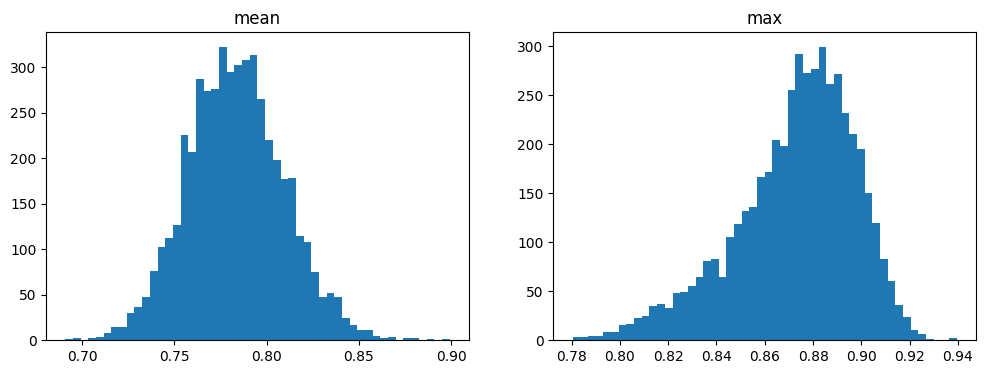

In [17]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

sample = df.sample(100, random_state=42)
sample_texts = sample["passage_text"].tolist()

results = {}
for strategy in ["mean", "max"]:
    emb = embed_passages(sample_texts, pooling=strategy, batch_size=16)
    sims = cosine_similarity(emb)
    pairwise = sims[np.triu_indices_from(sims, k=1)]
    results[strategy] = pairwise
    print(f"{strategy}: mean={pairwise.mean():.4f} std={pairwise.std():.4f} min={pairwise.min():.4f} max={pairwise.max():.4f}")

fig, axes = plt.subplots(1, len(results), figsize=(12, 4))
for ax, (strategy, pairwise) in zip(axes, results.items()):
    ax.hist(pairwise, bins=50)
    ax.set_title(strategy)
plt.show()

In [18]:
best_strategy = "mean"  # set based on step 7's results

embeddings = embed_passages(df["passage_text"].tolist(), pooling=best_strategy, batch_size=16)
df["embedding"] = list(embeddings)

In [19]:
!pip install hdbscan -q

In [20]:
import numpy as np

# df_valid from before — only rows with a real embedding
X = np.vstack(df["embedding"].values)
print(X.shape)  # (num_articles, 1024)

(2000, 1024)


In [22]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,      # smallest group of articles to count as an "event" — 2 is permissive, tune this
    min_samples=1,           # lower = less conservative about noise
    metric="euclidean",      # valid since vectors are L2-normalized
    cluster_selection_method="eom",  # "excess of mass" — usually better than "leaf" for uneven cluster sizes
)

df["cluster_id"] = clusterer.fit_predict(X)

In [23]:
print(df["cluster_id"].value_counts().head(20))
print("Noise (unclustered) articles:", (df["cluster_id"] == -1).sum())
print("Number of clusters found:", df["cluster_id"].nunique() - (1 if -1 in df["cluster_id"].values else 0))

cluster_id
-1      830
 270     13
 6       11
 207     10
 231      9
 357      8
 341      7
 229      7
 8        7
 411      7
 294      7
 93       7
 324      6
 335      6
 245      6
 379      6
 246      6
 138      6
 167      6
 117      6
Name: count, dtype: int64
Noise (unclustered) articles: 830
Number of clusters found: 414


In [26]:
for cid, group in list(df[df["cluster_id"] != -1].groupby("cluster_id"))[400:414]:
    print(f"=== Cluster {cid} ({len(group)} articles) ===")
    for title in group["title"]:
        print(f"- {title}")
    print()


=== Cluster 400 (4 articles) ===
- IMF: නව ආණ්ඩුව සමග පැමිණි එකඟතා මොනවා ද?
- වොෂිංටන් නුවරින් එන සුබ පණිවුඩය
- IMF: ශ්‍රී ලංකාවට වාහන ආනයනයට මාර්ග සිතියමක්
- ශ්‍රී ලංකාව ගැන මූඩීස් කරුණු පහදයි

=== Cluster 401 (5 articles) ===
- රාජ්‍ය සේවක වැටුප රු. 20,000ක් වැඩි කරන්න වැට් බද්ද සියයට 22ක් කරන්න වෙනවා
- 2024 ජනාධිපතිවරණය: රනිල්, සජිත්, අනුර සහ නාමල් රට පාලනය කරන්නේ කොහොම ද?
- Paye Tax නව වෙනස ඔබේ වැටුපට බලපාන්නේ කොහොම ද?
- රනිල්, සජිත්, අනුර, නාමල් රටට සල්ලි ගේන්නේ කොහොමද?
- රනිල්, සජිත්, අනුර, නාමල් යටතේ Paye Tax එකට මොකද වෙන්නේ ?

=== Cluster 402 (2 articles) ===
- රාජ්‍ය සේවක වැටුප් වැඩිකිරීම ගැන ඇමති විජිතගෙන් ප්‍රකාශයක්
- රාජ්‍ය සේවකයන්ට සැලකිය යුතු වැටුප් වැඩිවීමක්

=== Cluster 403 (4 articles) ===
- ස්වභාවික ආපදා තත්ත්වය හමුවේ රජය ක්‍රියා කළ ආකාරය ගැන UN වාර්තාවක් නිකුත් කරයි
- ‘‘දිට්වා‘‘ කුණාටුවෙන් දරුවන් 2,75,000 පීඩාවට
- ශ්‍රී ලංකාවේ ආපදා තත්ත්වයට උපකාර කිරීමට එක්සත් ජාතීන්ගේ සංවිධානය මානුෂීය සැලැස්මක් දියත් කරයි
- ’දිට්වා’ නිසා ආර්ථික වර්ධන වේගය වෙනස් කරන්නේ නෑ

=== Cluste